# Task 02 : Regression

Data Access Link : https://archive.ics.uci.edu/dataset/162/forest+fires

## 1. Dataset Description

The Forest Fires dataset contains 517 observations of forest fires in Montesinho Natural Park. It includes spatial, meteorological, and fire weather variables such as temperature, humidity, wind, rainfall, and drought indices. The objective of this regression analysis is to examine how meteorological conditions and fire-weather indices influence the burned area of forest fires and to evaluate the predictive performance of several regression models.

## 2. Data Loading & Cleaning 

In [1]:
import pandas as pd 
import numpy as np

In [2]:
df_ff = pd.read_csv(r"C:\Users\sbast\Downloads\forestfires.csv")

In [3]:
df_ff.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [4]:
df_ff.shape

(517, 13)

In [5]:
df_ff.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [6]:
df_ff.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [7]:
df_ff.isnull().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

In [8]:
df_ff.duplicated().sum()

4

In [9]:
df_ff = df_ff.drop_duplicates()

In [10]:
df_ff.duplicated().sum()

0

## 3. Exploratory Data Analysis (EDA)

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

### 3.1 Histogram

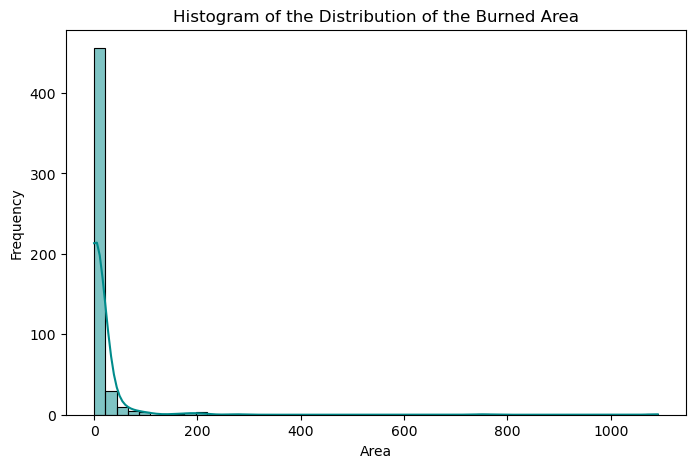

In [24]:
plt.figure(figsize = (8,5))

sns.histplot(df_ff["area"], bins = 50, color = "darkcyan", kde = True)

plt.title("Histogram of the Distribution of the Burned Area")
plt.xlabel("Area")
plt.ylabel("Frequency")
plt.show()

The histogram shows that the burned area variable is highly right-skewed. Most fires burn very small areas, while a few fires result in extremely large burned areas.

### 3.2 Histogram of the Logarithm

In [27]:
# Applying log transformation to reduce skewness

df_ff.loc[:, "log_area"] = np.log1p(df_ff["area"])

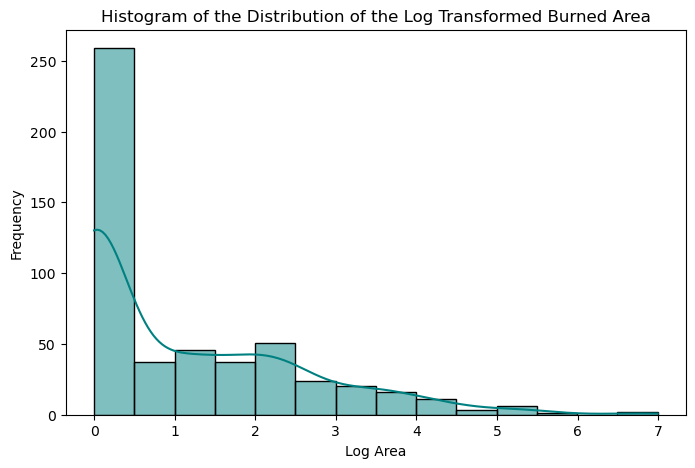

In [28]:
plt.figure(figsize = (8,5))

sns.histplot(df_ff["log_area"], kde = True, color = "Teal")

plt.title("Histogram of the Distribution of the Log Transformed Burned Area")
plt.xlabel("Log Area")
plt.ylabel("Frequency")

plt.show()

A log transformation is applied to reduce skewness in the burned area variable. The transformation log(1 + area) allows zero values to be included while compressing extreme values. This helps improve regression model performance.

### 3.3 Correlation Heatmap

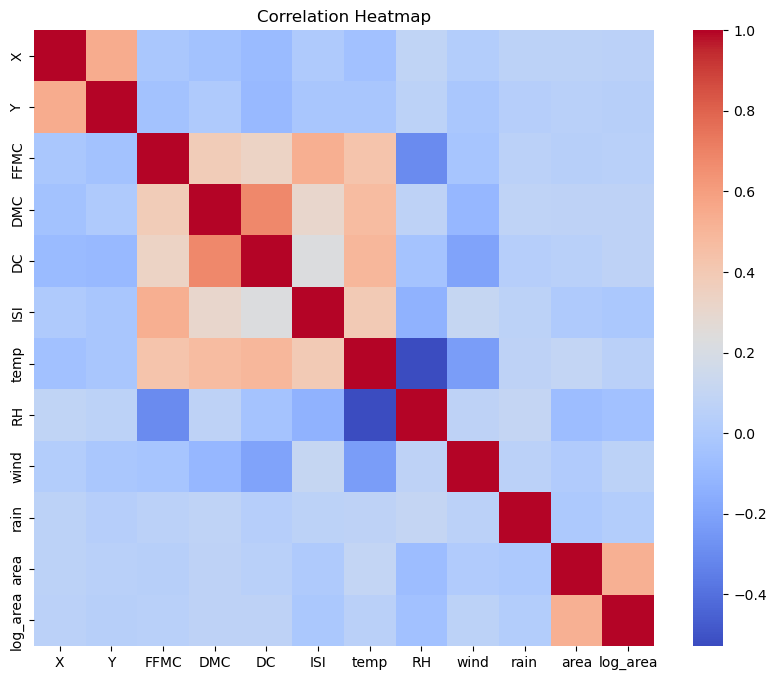

In [31]:
plt.figure(figsize = (10,8))

sns.heatmap(df_ff.corr(numeric_only = True), cmap = "coolwarm")

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows that most variables have weak correlations, with only a few moderate relationships (e.g., temperature with FFMC/DMC) and a strong correlation between area and log_area.

### 3.4 Scatterplot

#### 3.4.1 Scatterplot - Temperature vs Log Burned Area

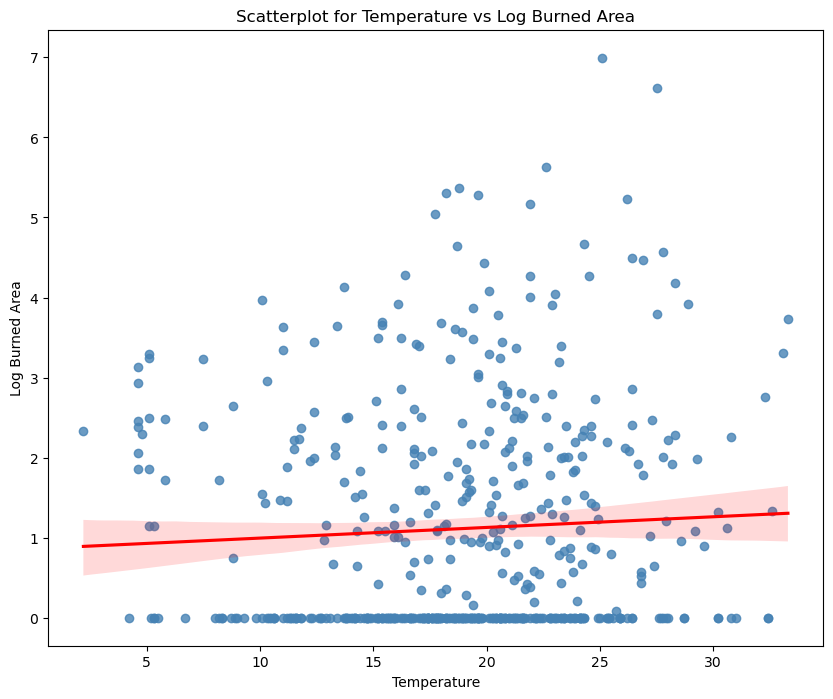

In [35]:
plt.figure(figsize = (10,8))

sns.regplot(x = "temp", y = "log_area", data = df_ff, scatter_kws = {"color": "steelblue"}, line_kws = {"color": "red"})

plt.title ("Scatterplot for Temperature vs Log Burned Area")

plt.xlabel("Temperature")

plt.ylabel("Log Burned Area")

plt.show()

The scatterplot illustrates the relationship between temperature and the log-transformed burned area. 
The points are widely dispersed, suggesting a weak relationship between temperature and fire size. 
The slight upward trend indicates that higher temperatures may slightly increase burned area, 
but the effect is limited.

#### 3.4.2 Scatterplot - Wind vs Log Burned Area

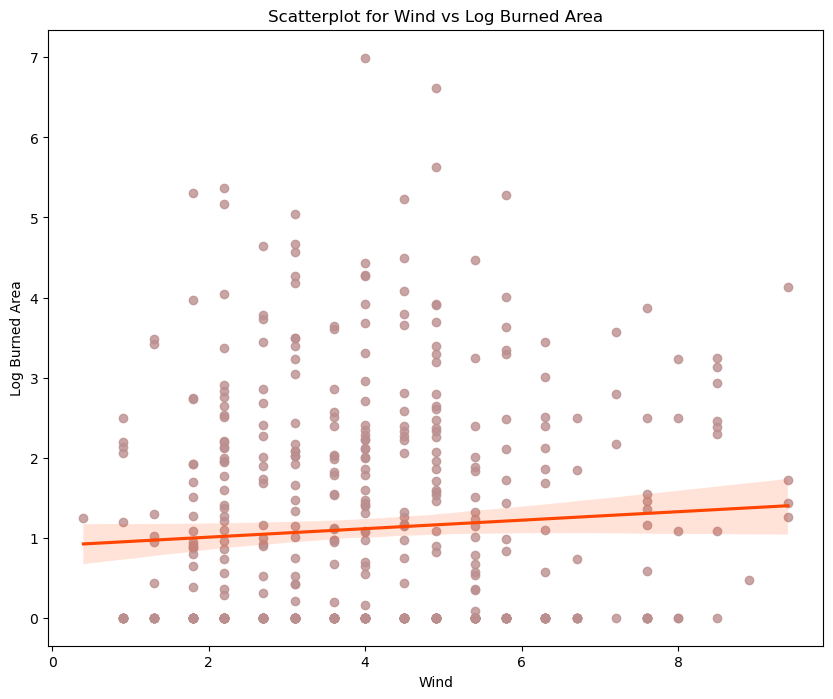

In [38]:
plt.figure(figsize = (10,8))

sns.regplot(x = "wind", y = "log_area", data = df_ff, scatter_kws = {"color": "rosybrown"}, line_kws = {"color": "orangered"})

plt.title ("Scatterplot for Wind vs Log Burned Area")

plt.xlabel("Wind")

plt.ylabel("Log Burned Area")

plt.show()

The scatterplot shows the relationship between wind speed and the log-transformed burned area. 
The wide spread of the points suggests that wind speed has a weak relationship with the size 
of the burned area.

## 4. Ecoding Categorical Variables

In [41]:
# converting categorical variables into numerical format

df_ff_encoded = pd.get_dummies(df_ff, columns=["month", "day"], drop_first=True)

In [42]:
df_ff_encoded.head()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,month_may,month_nov,month_oct,month_sep,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,...,False,False,False,False,False,False,False,False,False,False
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,...,False,False,True,False,False,False,False,False,True,False
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,...,False,False,True,False,False,True,False,False,False,False
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,...,False,False,False,False,False,False,False,False,False,False
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,...,False,False,False,False,False,False,True,False,False,False


The variables "month" and "day" are categorical and cannot be used directly by machine learning models. 
Therefore, one-hot encoding is applied to convert them into numerical features.

## 5. Model Training and Evaluation

In [46]:
# Defining the predictor and target variable

X = df_ff_encoded.drop(columns = ["area", "log_area"])

y = df_ff_encoded["log_area"]

The predictor variables include all environmental and meteorological features. 
The target variable is the log-transformed burned area, which reduces the skewness 
present in the original burned area variable.

In [48]:
# Importing relevant libraries for training and splitting the model 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [49]:
# Importing relevant libraries to standardise the feature variables

from sklearn.preprocessing import StandardScaler

scaler_ff = StandardScaler()

X_train_scaled_ff = scaler_ff.fit_transform(X_train)
X_test_scaled_ff = scaler_ff.transform(X_test)

### 5.1 Linear Regression

In [52]:
# Importing relevant libraries and training the linear regression model

from sklearn.linear_model import LinearRegression 

lr_model_ff = LinearRegression()

lr_model_ff.fit(X_train_scaled_ff, y_train)

LinearRegression()

In [54]:
# Predicting values

y_pred_lr_ff = lr_model_ff.predict(X_test_scaled_ff)

#### 5.1.1 Model Performance - Linear Regression

In [57]:
# Evaluating regression model performance

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_ff))

mae_lr = mean_absolute_error(y_test, y_pred_lr_ff)

r2_lr = r2_score(y_test, y_pred_lr_ff)

In [59]:
print("RMSE:", rmse_lr)

print("MAE:", mae_lr)

print("R²:", r2_lr)

RMSE: 1.2667937337256039
MAE: 1.0740204777614795
R²: 0.03938090180180809


The Linear Regression model shows the lowest prediction errors among the tested models. 
However, the small R² value indicates that the predictor variables explain only a limited 
portion of the variation in burned area, reflecting the difficulty of predicting forest fire size.

#### 5.1.2 Actual vs Predicted Plot - Linear Regression

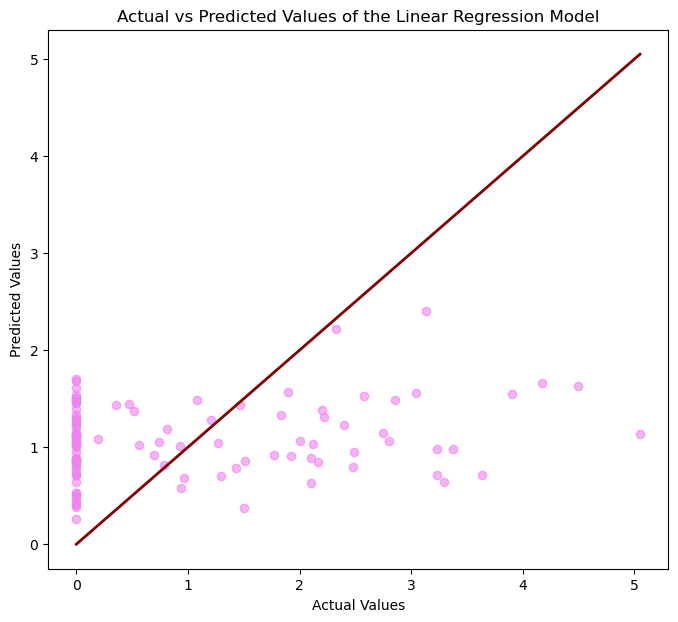

In [64]:
plt.figure(figsize = (8,7))

plt.scatter(y_test, y_pred_lr_ff, color = "violet", alpha = 0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "maroon", linewidth = 2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values of the Linear Regression Model")

plt.show()

The scatter shows that predictions deviate significantly from the ideal line, indicating the linear regression model has poor fit and low accuracy for this dataset.

## 5.2 Ridge Regression

In [67]:
from sklearn.linear_model import Ridge

# Ridge Regression

ridge_model_ff = Ridge(alpha = 1.0)

ridge_model_ff.fit(X_train, y_train)

y_pred_ridge_ff = ridge_model_ff.predict (X_test)

#### 5.2.1 Model Performance - Ridge Regression

In [69]:
# Evaluating regression model performance

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge_ff))

mae_ridge = mean_absolute_error(y_test, y_pred_ridge_ff)

r2_ridge = r2_score(y_test, y_pred_ridge_ff)

In [70]:
print("Ridge Regression")

print("RMSE:", rmse_ridge)

print("MAE:", mae_ridge)

print("R²:", r2_ridge)

Ridge Regression
RMSE: 1.265197455925133
MAE: 1.076542994349468
R²: 0.04180031512493587


The Ridge Regression model shows low predictive performance, with a very low R² indicating it explains almost none of the variance in the data.

#### 5.2.3 Residual Plot - Ridge Regression

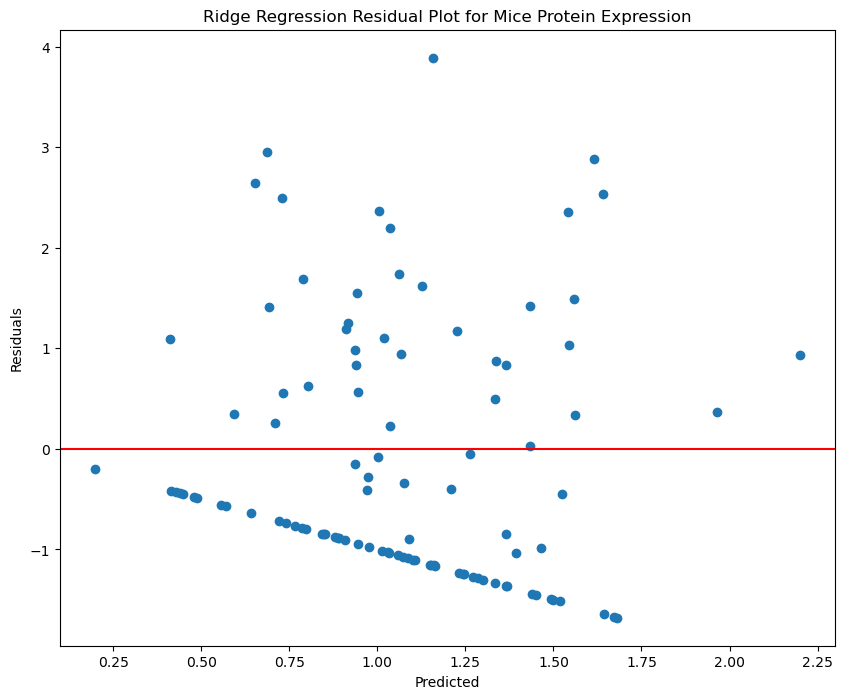

In [73]:
# Residual plot for Ridge regression

residuals_ridge_ff = y_test - y_pred_ridge_ff

plt.figure(figsize = (10,8))

plt.scatter(y_pred_ridge_ff, residuals_ridge_ff)

plt.axhline(0, color = "red")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Ridge Regression Residual Plot for Mice Protein Expression")

plt.show()

The residuals show a clear pattern rather than random scatter, indicating the Ridge model fails to capture underlying relationships and is poorly fitted.

#### 5.3.3 Actual vs Predicted Plot - Ridge Regression

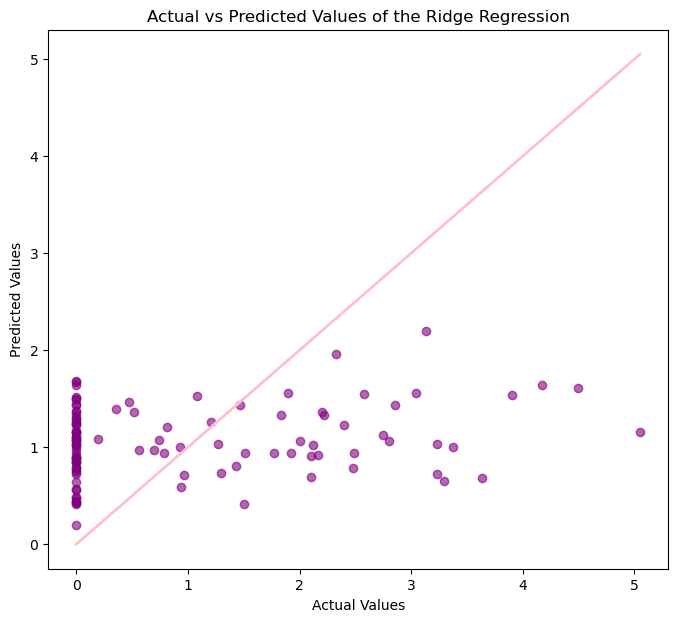

In [76]:
plt.figure(figsize = (8,7))

plt.scatter(y_test, y_pred_ridge_ff, color = "purple", alpha = 0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "pink", linewidth = 2)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values of the Ridge Regression")

plt.show()

The scatter shows predictions are poorly aligned with actual values and far from the ideal line, indicating weak performance of the Ridge Regression model.

## 5.3 Lasso Regression

In [79]:
from sklearn.linear_model import Lasso

lasso_model_ff = Lasso(alpha = 0.1)

lasso_model_ff.fit(X_train, y_train)

y_pred_lasso_ff = lasso_model_ff.predict(X_test)

#### 5.3.1 Model Performance - Lasso Regression

In [81]:
# Evaluating regression model performance

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso_ff))

mae_lasso = mean_absolute_error(y_test, y_pred_lasso_ff)

r2_lasso = r2_score(y_test, y_pred_lasso_ff)

In [82]:
print("Lasso Regression")

print("RMSE:", rmse_lasso)

print("MAE:", mae_lasso)

print("R²:", r2_lasso)

Lasso Regression
RMSE: 1.2814114870464164
MAE: 1.1172846227140327
R²: 0.017083491080466806


Lasso Regression performs poorly, with very low R² indicating almost no explanatory power.

#### 5.3.2 Residual Plot - Lasso Regression

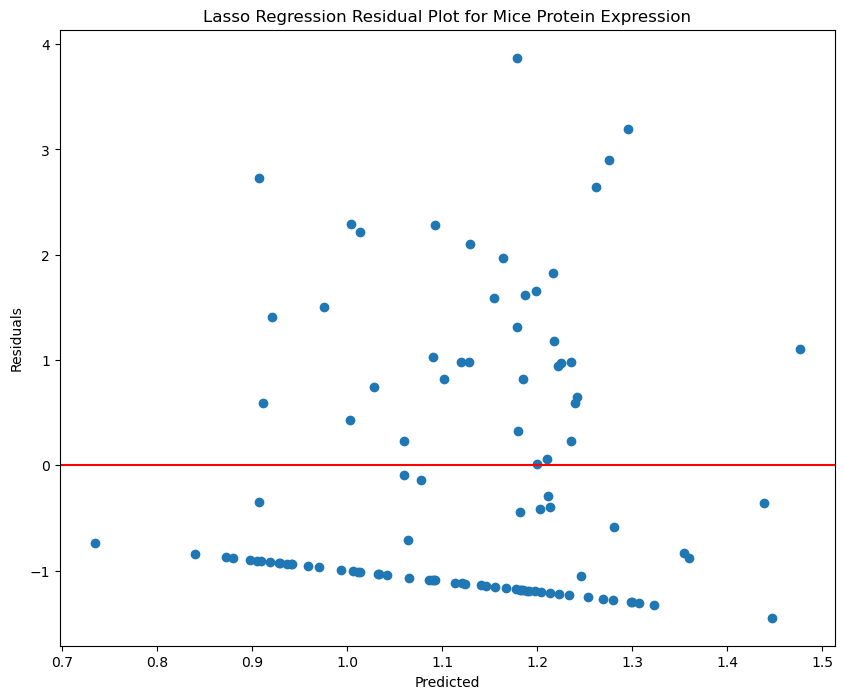

In [85]:
# Residual plot for Lasso regression

residuals_lasso_ff = y_test - y_pred_lasso_ff

plt.figure(figsize = (10,8))

plt.scatter(y_pred_lasso_ff, residuals_lasso_ff)

plt.axhline(0, color = "red")

plt.xlabel("Predicted")

plt.ylabel("Residuals")

plt.title("Lasso Regression Residual Plot for Mice Protein Expression")

plt.show()

Residuals of the Lasso Regression show a clear pattern, suggesting the model is not capturing the underlying relationship.

#### 5.3.3 Actual vs Predicted Plot - Lasso Regression

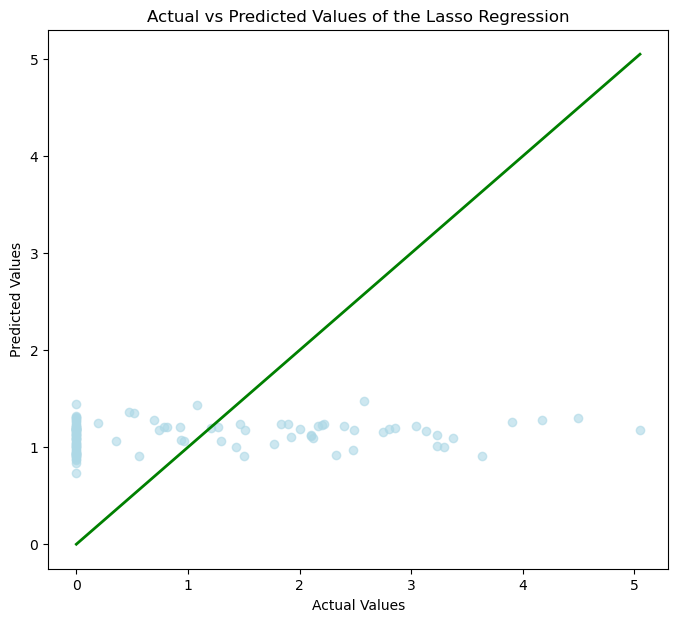

In [88]:
plt.figure(figsize = (8,7))

plt.scatter(y_test, y_pred_lasso_ff, color = "lightblue", alpha = 0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "green", linewidth = 2)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values of the Lasso Regression")

plt.show()

Predictions are clustered and far from the ideal line, indicating weak predictive accuracy.

### 5.4 Coefficient Comparison of the Ridge and Lasso Regression Models

<Figure size 1000x800 with 0 Axes>

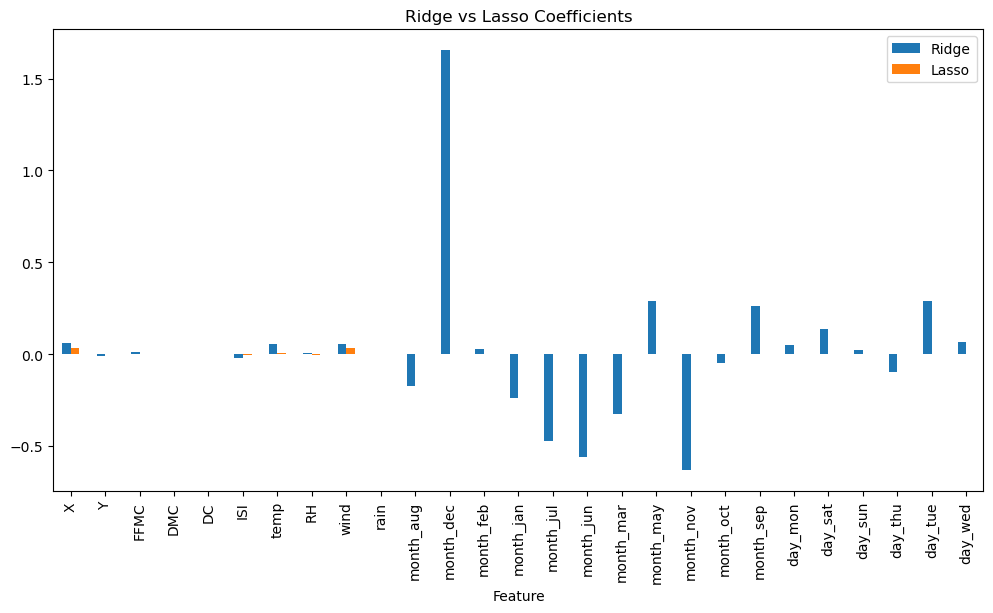

In [91]:
plt.figure(figsize = (10,8))

coeff_ff = pd.DataFrame({"Feature": X.columns,
                         "Ridge": ridge_model_ff.coef_,
                         "Lasso": lasso_model_ff.coef_})

coeff_ff.set_index("Feature").plot(kind="bar", figsize=(12,6))

plt.title("Ridge vs Lasso Coefficients")

plt.show()

Lasso applies stronger regularisation that drives many coefficients exactly to zero, effectively performing feature selection and keeping only the most important variables, whereas Ridge shrinks all coefficients but retains them, distributing influence across more features and capturing more subtle relationships.

### 5.5 Decision Tree Regression

In [94]:
# Importing relevant libraries and training the decision tree regressor

from sklearn.tree import DecisionTreeRegressor

dt_model_ff = DecisionTreeRegressor(random_state = 42)

dt_model_ff.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [95]:
# Predicting values

y_pred_dt_ff = dt_model_ff.predict(X_test)

#### 5.5.1 Model Performance - Decision Tree Regressor

In [97]:
# Evaluating regression model performance

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt_ff))

mae_dt = mean_absolute_error(y_test, y_pred_dt_ff)

r2_dt = r2_score(y_test, y_pred_dt_ff)

In [98]:
print("RMSE:", rmse_dt)

print("MAE:", mae_dt)

print("R²:", r2_dt)

RMSE: 1.9526674753364253
MAE: 1.3887999396952786
R²: -1.2824222310198925


The Decision Tree Regressor performs poorly on the forest fires dataset, as indicated by the negative R² value. This suggests that the model fails to capture meaningful relationships between the predictors and the burned area. This may be due to the highly skewed distribution of the target variable and the large number of zero values.

#### 5.5.2 Visualising the Decision Tree

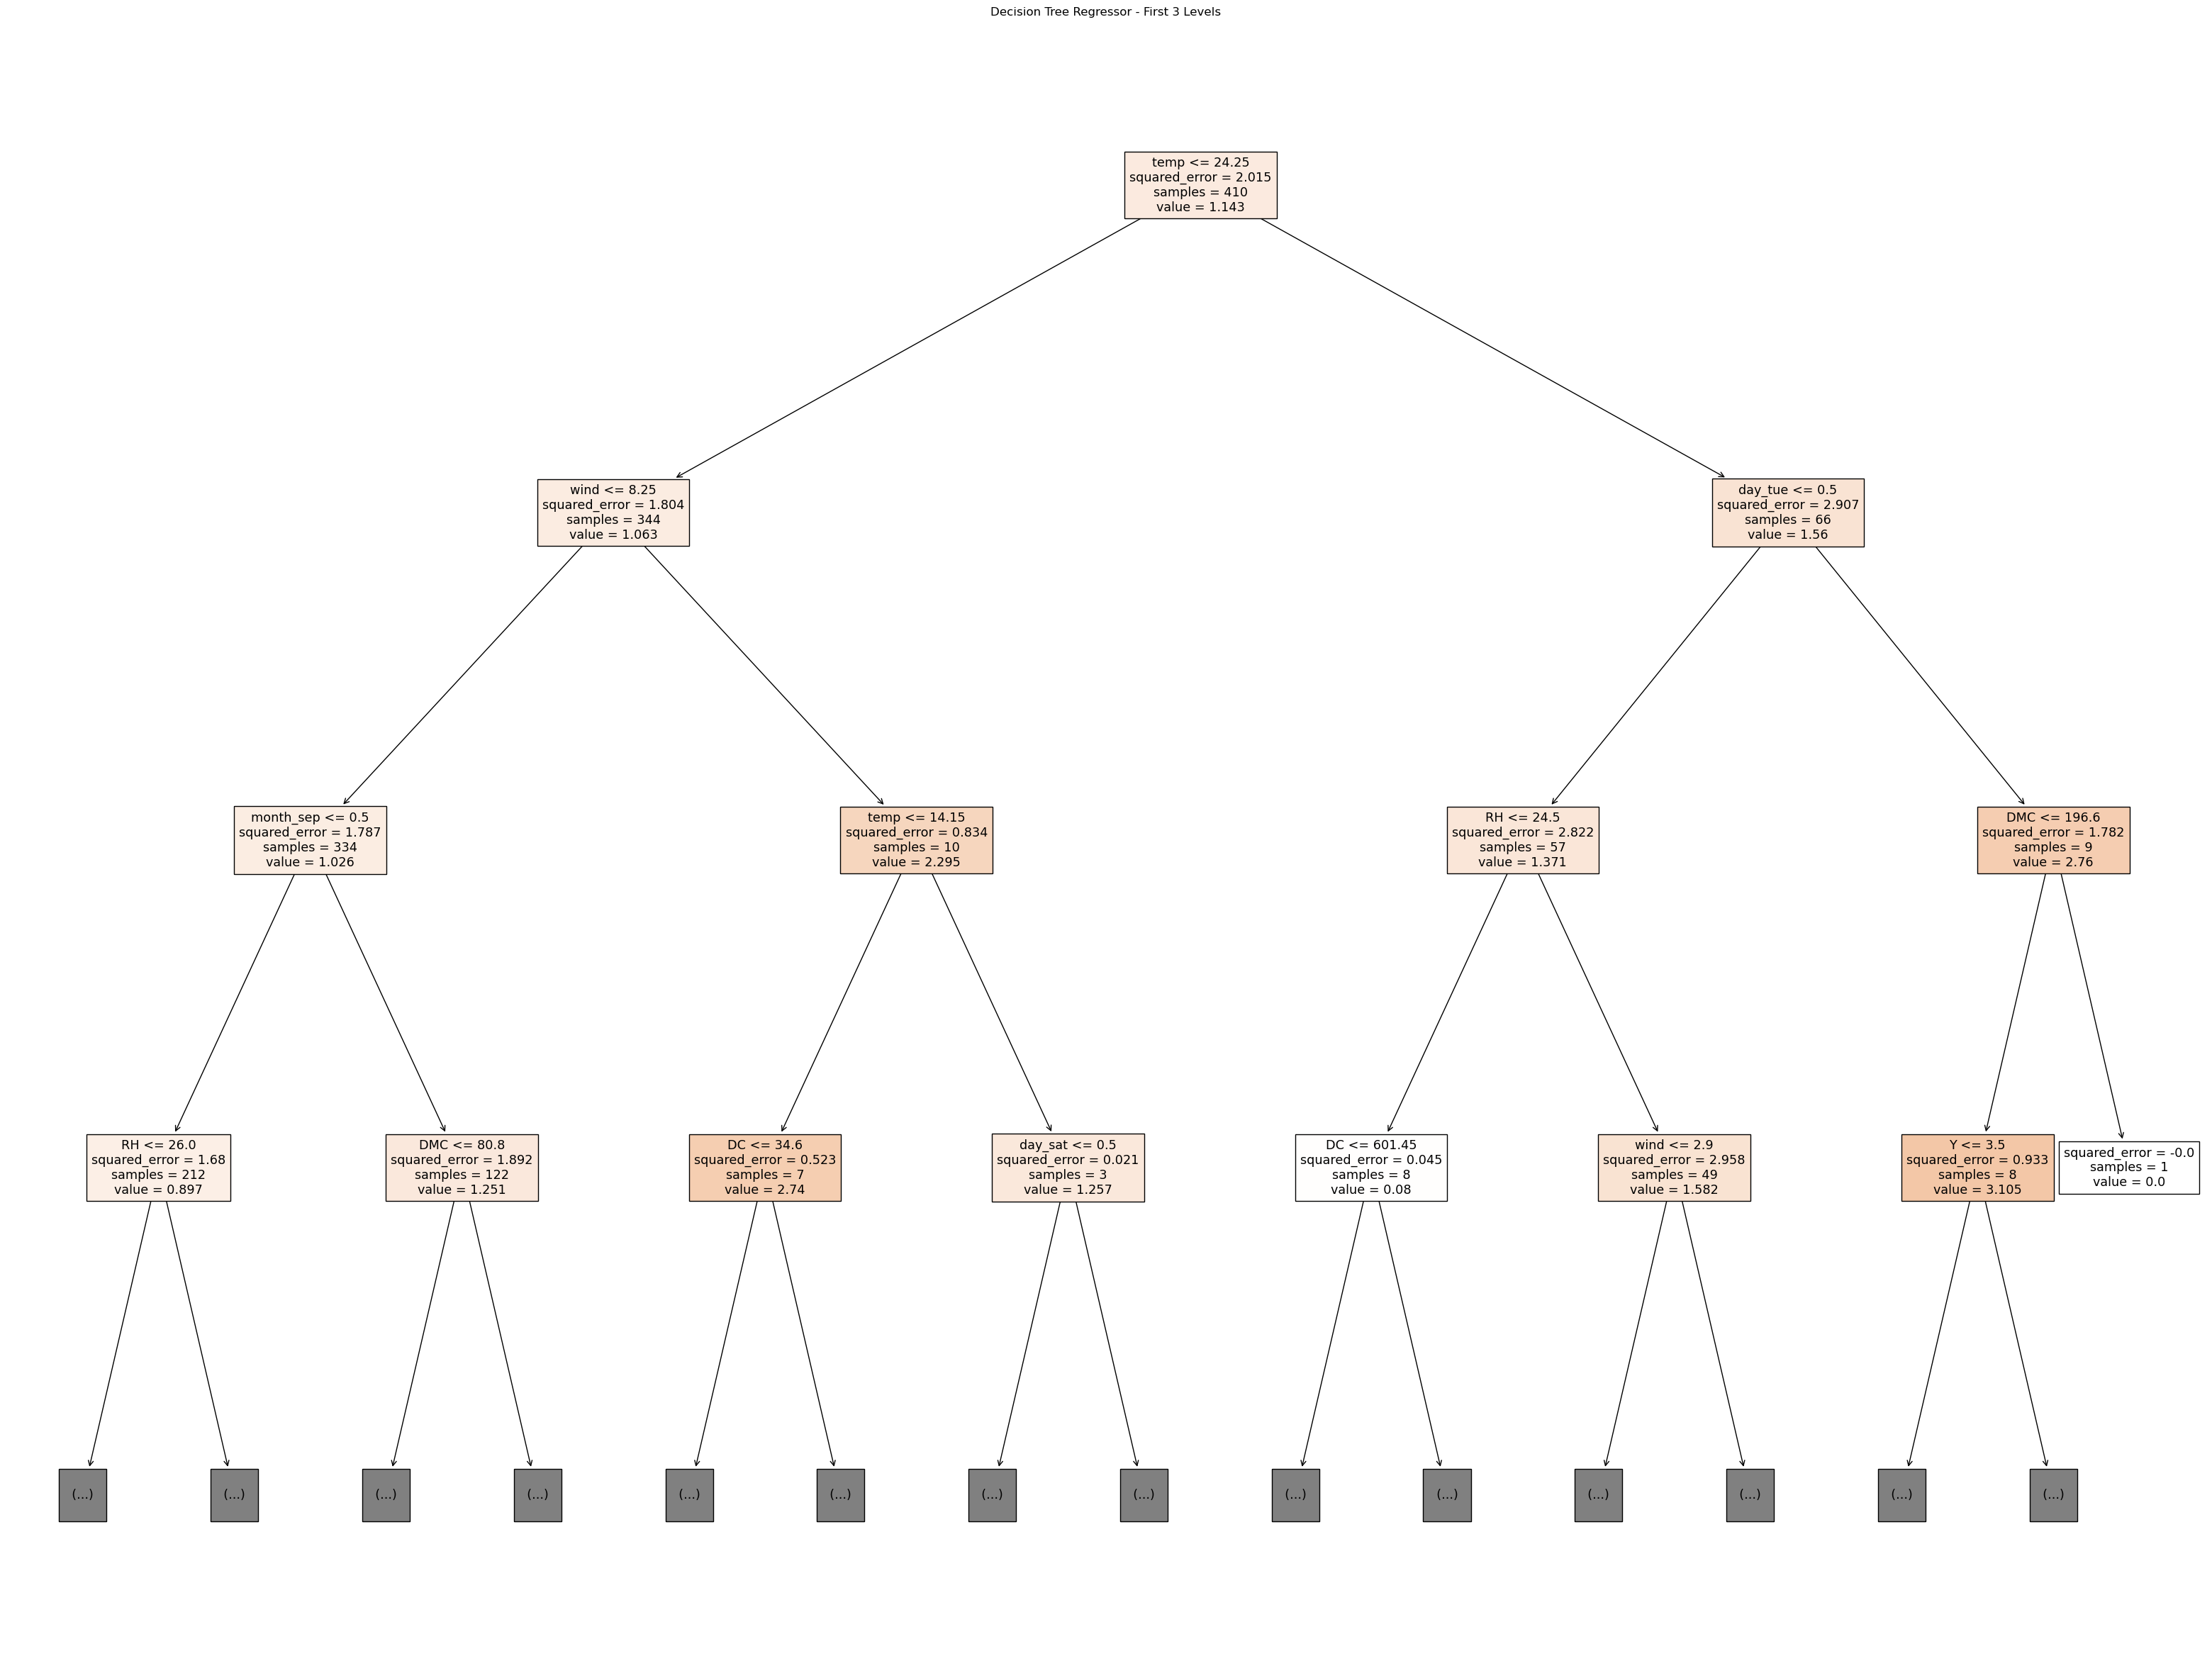

In [101]:
from sklearn.tree import plot_tree

plt.figure(figsize = (40,30))

plot_tree(dt_model_ff, feature_names = X.columns, filled = True, max_depth = 3)

plt.title("Decision Tree Regressor - First 3 Levels")

plt.show()

The decision tree structure is visualized to understand how the model splits the data based on different predictor variables. 
To improve readability, the tree depth is limited to the first three levels.

#### 5.5.3 Feature Importance 

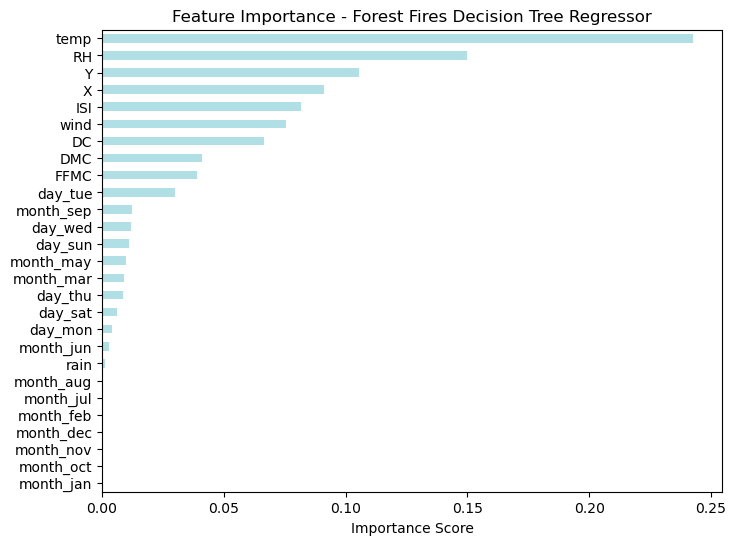

In [104]:
# Plotting a graph for the importance of each feature

importance_dt_ff = dt_model_ff.feature_importances_ # Extracting feature importance scores from the decision tree regressor

pd.Series(importance_dt_ff, index = X.columns).sort_values().plot(kind = "barh", figsize = (8,6), color = "powderblue") 

plt.title("Feature Importance - Forest Fires Decision Tree Regressor")

plt.xlabel("Importance Score")

plt.show()

Temperature and relative humidity are the most influential features, while most calendar-based variables contribute very little to predictions.

#### 5.5.4 Actual vs Predicted Plot - Decision Tree Regressor

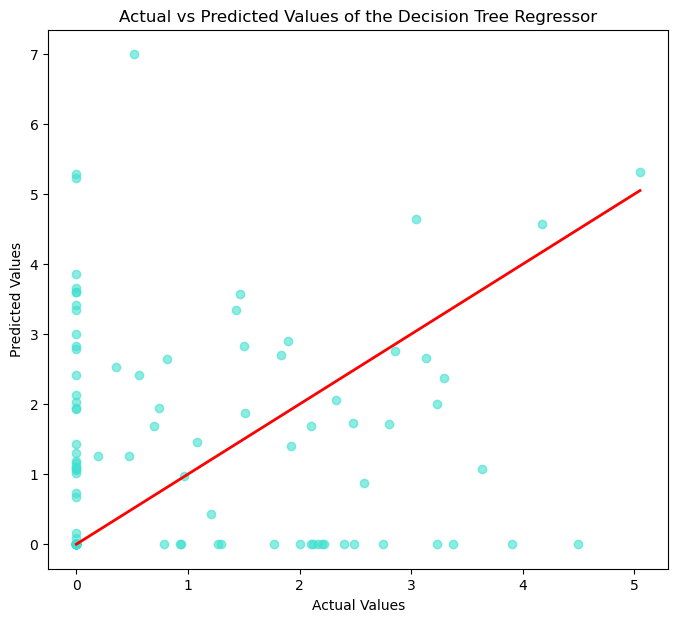

In [107]:
plt.figure(figsize = (8,7))

plt.scatter(y_test, y_pred_dt_ff, color = "turquoise", alpha = 0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "red", linewidth = 2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values of the Decision Tree Regressor")

plt.show()

Predictions are widely scattered and deviate from the ideal line, indicating poor model accuracy and overfitting.

### 5.6 Random Forest Regressor

In [110]:
# Importing relevant libraries and training the random forest regressor

from sklearn.ensemble import RandomForestRegressor

rf_model_ff = RandomForestRegressor(random_state = 42)

rf_model_ff.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [111]:
# Predicting values

y_pred_rf_ff = rf_model_ff.predict(X_test)

#### 5.6.1 Model Performance - Linear Regression

In [113]:
# Evaluating regression model performance

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_ff))

mae_rf = mean_absolute_error(y_test, y_pred_rf_ff)

r2_rf = r2_score(y_test, y_pred_rf_ff)

In [114]:
print("RMSE:", rmse_rf)

print("MAE:", mae_rf)

print("R²:", r2_rf)

RMSE: 1.336212254856651
MAE: 1.1333149858785956
R²: -0.06878488866350252


The Random Forest performs better than the Decision Tree with lower errors, but its near-zero R² indicates weak predictive power, likely due to the skewed target variable and weak feature relationships.

#### 5.6.2 Actual vs Predicted Plot - Random Forest Regressor

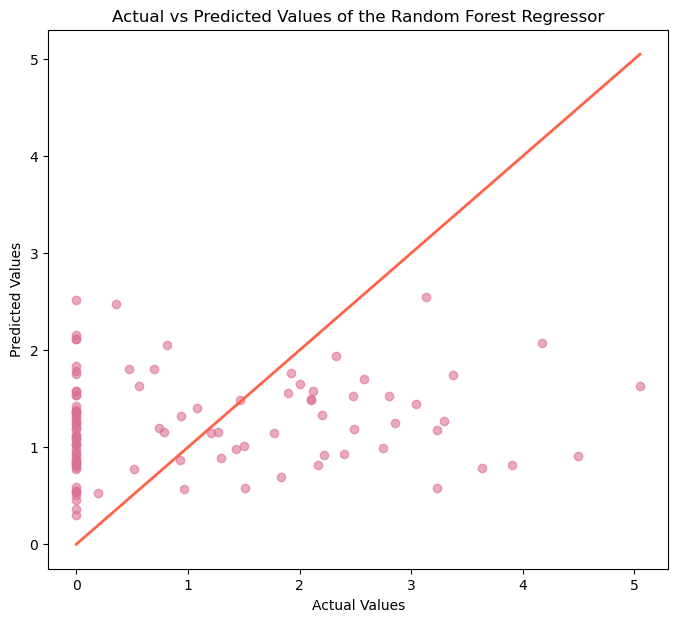

In [117]:
plt.figure(figsize = (8,7))

plt.scatter(y_test, y_pred_rf_ff, color = "palevioletred", alpha = 0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "tomato", linewidth = 2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values of the Random Forest Regressor")

plt.show()

Predictions are slightly more stable than the decision tree but still show weak alignment with actual values.

#### 5.6.3 Feature Importance 

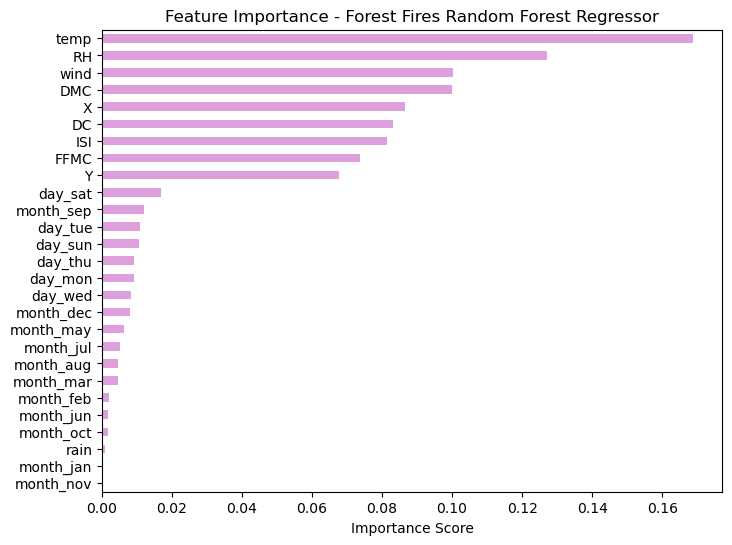

In [120]:
# Plotting a graph for the importance of each feature

importance_rf_ff = rf_model_ff.feature_importances_ # Extracting feature importance scores from the decision tree regressor

pd.Series(importance_rf_ff, index = X.columns).sort_values().plot(kind = "barh", figsize = (8,6), color = "plum") 

plt.title("Feature Importance - Forest Fires Random Forest Regressor")

plt.xlabel("Importance Score")

plt.show()

Temperature remains the dominant predictor, followed by humidity and wind-related variables, showing consistent feature influence across trees.

### 5.7 Model Comparison Table

In [143]:
results_ff = pd.DataFrame({"Model": ["Linear Regression","Ridge Regression", "Lasso Regression", "Decision Tree", "Random Forest"],
                           "RMSE": [rmse_lr, rmse_ridge, rmse_lasso, rmse_dt, rmse_rf],
                           "MAE": [mae_lr, mae_ridge, mae_lasso, mae_dt, mae_rf],
                           "R^2": [r2_lr, r2_ridge, r2_lasso, r2_dt, r2_rf]})

results_ff

,Model,RMSE,MAE,R^2
0,Linear Regression,1.266794,1.074020,0.039381
1,Ridge Regression,1.265197,1.076543,0.041800
2,Lasso Regression,1.281411,1.117285,0.017083
3,Decision Tree,1.952667,1.388800,-1.282422
4,Random Forest,1.336212,1.133315,-0.068785


Overall, all models demonstrate weak predictive performance, with very low or negative R² values indicating they fail to explain much of the variance in the data. Linear and Ridge Regression perform slightly better than the others, while Decision Tree performs the worst and Random Forest shows only minor improvement. This suggests the dataset has weak feature-target relationships and is difficult to model effectively.

## 6. Cross Validation of Each Model

In [147]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [148]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Linear Regression with scaling

lr_cv_ff = make_pipeline(StandardScaler(), LinearRegression())

cv_lr_ff = cross_val_score(lr_cv_ff, X, y, cv=kf, scoring="r2")

# Ridge Regression with scaling 

ridge_cv_ff = make_pipeline(StandardScaler(), Ridge(alpha = 1.0))

cv_ridge_ff = cross_val_score(ridge_cv_ff, X, y, cv=kf, scoring="r2")

# Lasso Regression with scaling 

lasso_cv_ff = make_pipeline(StandardScaler(), Lasso(alpha = 0.1))

cv_lasso_ff = cross_val_score(lasso_cv_ff, X, y, cv=kf, scoring="r2")

#Decision Tree

cv_dt_ff = cross_val_score(dt_model_ff, X, y, cv=kf, scoring="r2")

# Random Forest

cv_rf_ff = cross_val_score(rf_model_ff, X, y, cv=kf, scoring="r2")

### 6.1 Cross Validation Table for all Models

In [150]:
# Plotting the cross validation table with all models

cv_results_ff = pd.DataFrame({"Model": ["Linear Regression","Ridge Regression", "Lasso Regression", "Decision Tree", "Random Forest"],
                              "CV Mean R²": [cv_lr_ff.mean(),cv_ridge_ff.mean(), cv_lasso_ff.mean(), cv_dt_ff.mean(), cv_rf_ff.mean() ],
                              "CV Std Dev": [cv_lr_ff.std(), cv_ridge_ff.std(), cv_lasso_ff.std(), cv_dt_ff.std(),cv_rf_ff.std()]})

cv_results_ff

,Model,CV Mean R²,CV Std Dev
0,Linear Regression,-0.260869,0.444766
1,Ridge Regression,-0.259327,0.445150
2,Lasso Regression,-0.004421,0.018851
3,Decision Tree,-0.870169,0.274573
4,Random Forest,-0.121250,0.052278


The table shows that all models have low or negative R² values, indicating weak predictive performance, with Linear and Ridge performing relatively better while Decision Tree performs the worst.

### 6.2 A plot of the cross-validation results

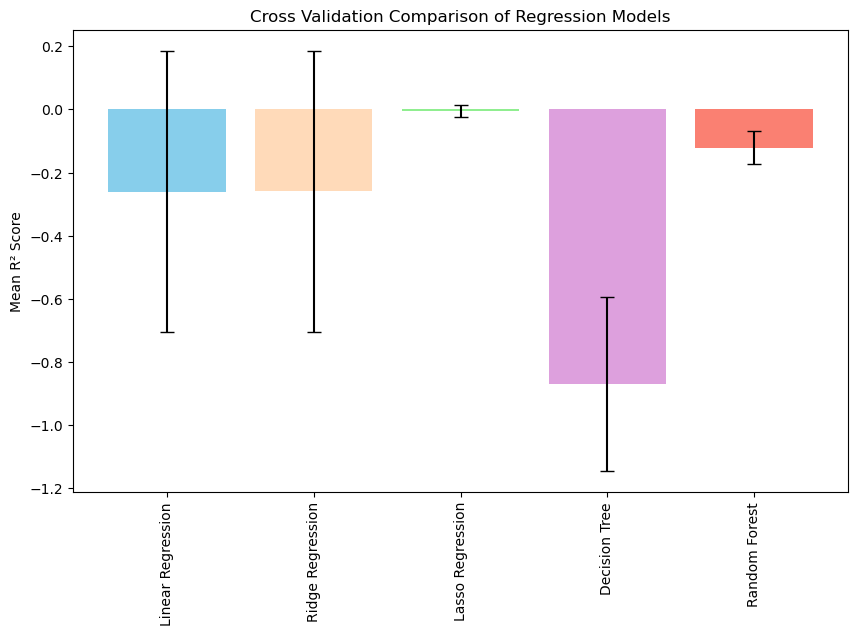

In [153]:
plt.figure(figsize=(10,6))

plt.bar(cv_results_ff["Model"], cv_results_ff["CV Mean R²"], yerr=cv_results_ff["CV Std Dev"], capsize=5, color=["skyblue","peachpuff","lightgreen", "plum", "salmon"])

plt.title("Cross Validation Comparison of Regression Models")

plt.ylabel("Mean R² Score")

plt.xticks(rotation = 90)

plt.show()

The bar plot compares the average R² scores obtained from 5-fold cross-validation 
for the regression models. The results indicate that the models generally achieve 
low predictive performance on this dataset, which is expected due to the highly 
skewed distribution of burned areas and the weak relationship between the predictor 
variables and the target variable.

## 7. Conclusion

Overall, the models demonstrate limited predictive capability, with most showing low or negative R² values, indicating they struggle to capture meaningful patterns in the data. While Linear and Ridge Regression perform relatively better, their performance remains weak, suggesting that linear relationships between the predictors and the target variable are limited. 

Although Random Forest slightly improves upon Decision Tree, it does not significantly enhance predictive accuracy, indicating that even more flexible, non-linear models are unable to fully capture the underlying structure of the data. This may be attributed to the highly skewed nature of the target variable, with many small fire events and few large ones, as well as weak relationships between the features and the outcome. 

Furthermore, the results highlight the inherent difficulty of predicting forest fire area, which is influenced by complex and stochastic environmental factors such as weather conditions and wind patterns.